In [1]:
# %%
# 最终
import os
import sys
import shutil
import time
import random
import argparse
import torch
import torch.backends.cudnn as cudnn
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as dset
import torchvision.transforms as transforms
from utils_.utils import AverageMeter, RecorderMeter, time_string, convert_secs2time
import models
import copy
import numpy as np
from models.attack_model import Attack
from models.nomarlization_layer import Normalize_layer, noise_Normalize_layer
from numpy.random import RandomState
import copy
import matplotlib.cm as cm
from matplotlib.colors import Normalize

In [2]:
# %%

from argparse import Namespace
# 创建一个命名空间对象
args = Namespace()
args.dataset = 'cifar10'
args.adv_eval = False
args.data_path = '/home/xueqiong/CVPR_2019_PNI-master/data'
args.batch_size = 128
args.workers = 4
args.input_noise = False
args.learning_rate = 0.1
args.momentum = 0.9
args.decay = 0.0003
args.fine_tune = False
# -------------上面的基本上不用动，下面的要改
args.use_cuda = False
args.adv_train = False
args.ngpu = 1
args.save_path = '/home/xueqiong/noise_injection_uncertainty/cifar10/save/final_res_resnet8/qualitative_analysis'
args.manualSeed = 123
args.optimizer = 'SGD'

In [3]:
# %%

def print_log(print_string, log):
    print("{}".format(print_string))
    log.write('{}\n'.format(print_string))
    log.flush()

In [4]:
# %%

# Init logger
if not os.path.isdir(args.save_path):
    os.makedirs(args.save_path)
log = open(os.path.join(args.save_path,
                        'log_seed_{}.txt'.format(args.manualSeed)), 'w')
if args.use_cuda == False:
    print_log('No GPU!', log)
    print_log('{},{}'.format(args.ngpu,torch.cuda.is_available()), log)
print_log('save path : {}'.format(args.save_path), log)
state = {k: v for k, v in args._get_kwargs()}
print_log(state, log)
print_log("Random Seed: {}".format(args.manualSeed), log)
print_log("python version : {}".format(
    sys.version.replace('\n', ' ')), log)
print_log("torch  version : {}".format(torch.__version__), log)
print_log("cudnn  version : {}".format(
    torch.backends.cudnn.version()), log)

# Init the tensorboard path and writer
tb_path = os.path.join(args.save_path, 'tb_log')

No GPU!
1,True
save path : /home/xueqiong/noise_injection_uncertainty/cifar10/save/final_res_resnet8/qualitative_analysis
{'dataset': 'cifar10', 'adv_eval': False, 'data_path': '/home/xueqiong/CVPR_2019_PNI-master/data', 'batch_size': 128, 'workers': 4, 'input_noise': False, 'learning_rate': 0.1, 'momentum': 0.9, 'decay': 0.0003, 'fine_tune': False, 'use_cuda': False, 'adv_train': False, 'ngpu': 1, 'save_path': '/home/xueqiong/noise_injection_uncertainty/cifar10/save/final_res_resnet8/qualitative_analysis', 'manualSeed': 123, 'optimizer': 'SGD'}
Random Seed: 123
python version : 3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 15:12:24) [GCC 11.2.0]
torch  version : 2.4.1+cu124
cudnn  version : 90100


In [5]:
# %%

if args.dataset == 'cifar10':
    mean = [x / 255 for x in [125.3, 123.0, 113.9]]
    std = [x / 255 for x in [63.0, 62.1, 66.7]]
elif args.dataset == 'cifar100':
    mean = [x / 255 for x in [129.3, 124.1, 112.4]]
    std = [x / 255 for x in [68.2, 65.4, 70.4]]
elif args.dataset == 'svhn':
    mean = [0.5, 0.5, 0.5]
    std = [0.5, 0.5, 0.5]
elif args.dataset == 'mnist':
    mean = [0.5, 0.5, 0.5]
    std = [0.5, 0.5, 0.5]
elif args.dataset == 'imagenet':
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
else:
    assert False, "Unknow dataset : {}".format(args.dataset)

# Current data-preprocessing does not include the normalization
imagenet_train_transform = [
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()]
imagenet_test_transform = [
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor()]

normal_train_transform = [
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor()]
normal_test_transform = [
    transforms.ToTensor()]

# if not performing the adversarial training or evalutaion, we append
# the normalization back to the preprocessing
if not (args.adv_train or args.adv_eval):
    imagenet_train_transform.append(transforms.Normalize(mean, std))
    imagenet_test_transform.append(transforms.Normalize(mean, std))
    normal_train_transform.append(transforms.Normalize(mean, std))
    normal_test_transform.append(transforms.Normalize(mean, std))

if args.dataset == 'imagenet':
    train_transform = transforms.Compose(imagenet_train_transform)
    test_transform = transforms.Compose(imagenet_test_transform)
else:
    train_transform = transforms.Compose(normal_train_transform)
    test_transform = transforms.Compose(normal_test_transform)

if args.dataset == 'mnist':
    train_data = dset.MNIST(
        args.data_path, train=True, transform=train_transform, download=True)
    test_data = dset.MNIST(args.data_path, train=False,
                            transform=test_transform, download=True)
    num_classes = 10
elif args.dataset == 'cifar10':
    train_data = dset.CIFAR10(
        args.data_path, train=True, transform=train_transform, download=True)
    test_data = dset.CIFAR10(
        args.data_path, train=False, transform=test_transform, download=True)
    num_classes = 10
elif args.dataset == 'cifar100':
    train_data = dset.CIFAR100(
        args.data_path, train=True, transform=train_transform, download=True)
    test_data = dset.CIFAR100(
        args.data_path, train=False, transform=test_transform, download=True)
    num_classes = 100
elif args.dataset == 'svhn':
    train_data = dset.SVHN(args.data_path, split='train',
                            transform=train_transform, download=True)
    test_data = dset.SVHN(args.data_path, split='test',
                            transform=test_transform, download=True)
    num_classes = 10
elif args.dataset == 'stl10':
    train_data = dset.STL10(
        args.data_path, split='train', transform=train_transform, download=True)
    test_data = dset.STL10(args.data_path, split='test',
                            transform=test_transform, download=True)
    num_classes = 10
elif args.dataset == 'imagenet':
    train_dir = os.path.join(args.data_path, 'train')
    test_dir = os.path.join(args.data_path, 'val')
    train_data = dset.ImageFolder(train_dir, transform=train_transform)
    test_data = dset.ImageFolder(test_dir, transform=test_transform)
    num_classes = 1000
else:
    assert False, 'Do not support dataset : {}'.format(args.dataset)

test_loader = torch.utils.data.DataLoader(test_data, batch_size=args.batch_size, shuffle=False,
                                            num_workers=args.workers, pin_memory=True)

Files already downloaded and verified
Files already downloaded and verified


In [6]:
# %%

def accuracy(output, target, topk=(1,)):
    """Computes the precision@k for the specified values of k"""
    with torch.no_grad():
        maxk = max(topk)
        batch_size = target.size(0)

        _, pred = output.topk(maxk, 1, True, True)
        pred = pred.t()
        correct = pred.eq(target.view(1, -1).expand_as(pred))

        res = []
        for k in topk:
            correct_k = correct[:k].contiguous().view(-1).float().sum(0)
            res.append(correct_k.mul_(100.0 / batch_size))

        return res
    
def validate(val_loader, model, criterion, log, test_times=10):
    losses = AverageMeter()
    acc_avg = AverageMeter()
    # switch to evaluate mode
    model.eval()
    recursive_module_iteration(model)

    for i, (input, target) in enumerate(val_loader):
        if args.use_cuda:
            target = target.cuda(non_blocking=True)
            input = input.cuda()
        logits = torch.zeros((input.shape[0], num_classes, test_times))
        for i in range(test_times):
            # compute output
            output = model(input)
            logits[:, :, i] = output
        avg_logits = torch.mean(logits, dim=2)
        var_logits = torch.sum(torch.var(logits, dim=2), dim=-1)
        loss = criterion(avg_logits, target)
        # measure accuracy and record loss
        prec1, prec5 = accuracy(avg_logits.data, target, topk=(1, 5))
        acc_avg.update(prec1.item(), input.size(0))

    print_log(
    '  **Test** Prec@1 {top1.avg:.3f}'.format(top1=acc_avg), log)
    return acc_avg

def validate2(val_loader, model, criterion, log, test_times=10, return_detail=False):
    losses = AverageMeter()
    acc_avg = AverageMeter()
    # switch to evaluate mode
    samplesize = val_loader.dataset.data.shape[0]
    model.eval()
    if 'dropout' in args.arch:
        recursive_module_iteration(model)
    with torch.no_grad():
        var_softmaxs_all = []
        pred_all = []
        avg_logits_all = []
        for i, (input, target) in enumerate(val_loader):
            logits = torch.zeros((input.shape[0], num_classes, test_times))
            softmaxs = torch.zeros((input.shape[0], num_classes, test_times))
            if args.use_cuda:
                target = target.cuda(non_blocking=True)
                input = input.cuda()
                logits = logits.cuda()
            for i in range(test_times):
                # compute output
                output = model(input)
                logits[:, :, i] = output
                softmaxs[:, :, i] = F.softmax(output, dim=1)
            avg_logits = torch.mean(logits, dim=2)
            var_softmaxs = torch.sum(torch.var(softmaxs, dim=2), dim=-1)   # [batch_size]
            var_softmaxs = var_softmaxs.numpy().tolist()
            loss = criterion(avg_logits, target)
            # measure accuracy and record loss
            prec1, prec5 = accuracy(avg_logits.data, target, topk=(1, 5))
            acc_avg.update(prec1.item(), input.size(0))
            _, pred = output.topk(1, 1, True, True)
            pred = pred.t()[0].numpy().tolist()
            if return_detail:
                var_softmaxs_all.extend(var_softmaxs)
                pred_all.extend(pred)
                avg_logits_all.extend(avg_logits)

    print_log(
    '  **Test** Prec@1 {top1.avg:.3f}'.format(top1=acc_avg), log)
    return acc_avg, var_softmaxs_all, pred_all, avg_logits_all

def predict(input, model, test_times=10):
    losses = AverageMeter()
    acc_avg = AverageMeter()
    # switch to evaluate mode
    model.eval()
    recursive_module_iteration(model)

    if args.use_cuda:
        target = target.cuda(non_blocking=True)
        input = input.cuda()
    logits = torch.zeros((input.shape[0], num_classes, test_times))
    for i in range(test_times):
        # compute output
        output = model(input)
        logits[:, :, i] = output
    avg_logits = torch.mean(logits, dim=2)

    return avg_logits.argmax().item()

In [7]:
# %%

def plot_softmax(inputs, target, model, x, test_times=100):
    model.eval()
    recursive_module_iteration(model)
    inputs = inputs.unsqueeze(0)
    target = torch.tensor([target])
    acc_avg = AverageMeter()
    if args.use_cuda:
        target = target.cuda(non_blocking=True)
        inputs = inputs.cuda()
    logits = torch.zeros((inputs.shape[0], num_classes, test_times))
    for i in range(test_times):
        # compute output
        output = net(inputs)
        logits[:, :, i] = output
    avg_logits = torch.mean(logits, dim=2)
    loss = criterion(avg_logits, target)
    # measure accuracy and record loss
    prec1, prec5 = accuracy(avg_logits.data, target, topk=(1, 5))
    acc_avg.update(prec1.item(), inputs.size(0))
    softmax = np.exp(logits[0].detach().numpy()) / np.sum(np.exp(logits[0].detach().numpy()), axis=0)
    # print('sum')
    # print(np.sum(softmax, axis=0).shape)
    # print(np.sum(softmax, axis=0))
    line_lengths = 0.5
    for i in range(softmax.shape[-1]):
        plt.hlines(softmax[target[0], i], x - line_lengths / 2, x + line_lengths / 2, linewidth=0.5)
    return softmax

def plot_softmaxs(inputs, targets, model, x, test_times=100):
    model.eval()
    recursive_module_iteration(model)
    inputs = inputs.unsqueeze(0)
    colors = plt.cm.Set1(np.linspace(0, 1, len(targets)))
    marked_lines = []

    for value, target in enumerate(targets):
        target = torch.tensor([target])
        acc_avg = AverageMeter()
        if args.use_cuda:
            target = target.cuda(non_blocking=True)
            inputs = inputs.cuda()
        logits = torch.zeros((inputs.shape[0], num_classes, test_times))
        for i in range(test_times):
            # compute output
            output = net(inputs)
            logits[:, :, i] = output
        avg_logits = torch.mean(logits, dim=2)
        loss = criterion(avg_logits, target)
        # measure accuracy and record loss
        prec1, prec5 = accuracy(avg_logits.data, target, topk=(1, 5))
        acc_avg.update(prec1.item(), inputs.size(0))
        softmax = np.exp(logits[0].detach().numpy()) / np.sum(np.exp(logits[0].detach().numpy()), axis=0)
        # print('sum')
        # print(np.sum(softmax, axis=0).shape)
        # print(np.sum(softmax, axis=0))
        line_lengths = 0.5
        for i in range(softmax.shape[-1]):
            line = plt.hlines(softmax[target[0], i], x - line_lengths / 2, x + line_lengths / 2, linewidth=0.5, color=colors[value], label=target)
            if i == 0:
                marked_lines.append(line)
    return softmax, marked_lines

def plot_softmaxs_ax(inputs, targets, model, x, ax, test_times=100):
    model.eval()
    recursive_module_iteration(model)
    inputs = inputs.unsqueeze(0)
    colors = plt.cm.Set1(np.linspace(0, 1, len(targets)))
    marked_lines = []

    for value, target in enumerate(targets):
        target = torch.tensor([target])
        acc_avg = AverageMeter()
        if args.use_cuda:
            target = target.cuda(non_blocking=True)
            inputs = inputs.cuda()
        logits = torch.zeros((inputs.shape[0], num_classes, test_times))
        for i in range(test_times):
            # compute output
            output = net(inputs)
            logits[:, :, i] = output
        avg_logits = torch.mean(logits, dim=2)
        loss = criterion(avg_logits, target)
        # measure accuracy and record loss
        prec1, prec5 = accuracy(avg_logits.data, target, topk=(1, 5))
        acc_avg.update(prec1.item(), inputs.size(0))
        softmax = np.exp(logits[0].detach().numpy()) / np.sum(np.exp(logits[0].detach().numpy()), axis=0)
        # print('sum')
        # print(np.sum(softmax, axis=0).shape)
        # print(np.sum(softmax, axis=0))
        line_lengths = 0.5
        for i in range(softmax.shape[-1]):
            line = ax.hlines(softmax[target[0], i], x - line_lengths / 2, x + line_lengths / 2, linewidth=0.5, color=colors[value], label=target)
            if i == 0:
                marked_lines.append(line)
    return softmax, marked_lines

In [8]:
# %%

def plot_logits(inputs, target, model, x, test_times=100):
    model.eval()
    recursive_module_iteration(model)
    inputs = inputs.unsqueeze(0)
    target = torch.tensor([target])
    acc_avg = AverageMeter()
    if args.use_cuda:
        target = target.cuda(non_blocking=True)
        inputs = inputs.cuda()
    logits = torch.zeros((inputs.shape[0], num_classes, test_times))
    for i in range(test_times):
        # compute output
        output = net(inputs)
        logits[:, :, i] = output
    avg_logits = torch.mean(logits, dim=2)
    loss = criterion(avg_logits, target)
    # measure accuracy and record loss
    prec1, prec5 = accuracy(avg_logits.data, target, topk=(1, 5))
    acc_avg.update(prec1.item(), inputs.size(0))
    logits = logits[0].detach().numpy()
    line_lengths = 0.5
    for i in range(logits.shape[-1]):
        plt.hlines(logits[target[0], i], x - line_lengths / 2, x + line_lengths / 2, linewidth=0.5)
    return logits

In [9]:
# %%

def init_net():
    args.resume_path = '/home/xueqiong/noise_injection_uncertainty/cifar10/save/final_res_resnet8/{}'.format(folder)
    if 'fixnoise_resnet20' in folder:
        args.arch = 'fixnoise_resnet20'
        args.fix_noise_level = float(folder.split('_')[-1])
        print('fix_noise_level: ', args.fix_noise_level)
    elif 'fixnoise_resnet8' in folder:
        args.arch = 'fixnoise_resnet8'
        args.fix_noise_level = float(folder.split('_')[-1])
        print('fix_noise_level: ', args.fix_noise_level)
    elif 'noise_resnet20' in folder:
        args.arch = 'noise_resnet20'
    elif 'noise_resnet8' in folder:
        args.arch = 'noise_resnet8'
    elif 'dropout_resnet20' in folder:
        args.arch = 'dropout_resnet20'
    elif 'dropout_resnet8' in folder:
        args.arch = 'dropout_resnet8'
    elif 'vanilla_resnet20' in folder:
        args.arch = 'vanilla_resnet20'
    elif 'vanilla_resnet8' in folder:
        args.arch = 'vanilla_resnet8'
    args.num_filters = 4

    print('arch: ', args.arch)
    net = init_model(args, num_classes, args.num_filters)
    print_log("=> network :\n {}".format(net), log)
    return net

In [10]:
# %%

def noise_img(inputs, std):
    # inputs需要是[0, 255]的，(32, 32, 3)
    noise = np.random.randn(*inputs.shape)
    noise_inputs = inputs + noise*std*255
    noise_inputs = np.clip(noise_inputs, 0, 255)
    noise_inputs = np.transpose(noise_inputs, (2, 0, 1))
    noise_inputs = noise_inputs.astype("uint8")
    noise_inputs = torch.from_numpy(noise_inputs)
    # 输出的inputs也是[0, 255]，(3, 32, 32)
    return noise_inputs

In [11]:
from matplotlib import pyplot as plt

In [12]:
# %%

def init_model(args, num_classes, num_filters):
    # Init model, criterion, and optimizer
    if 'fixnoise' not in args.arch:
        net_c = models.__dict__[args.arch](num_classes, num_filters)
    else:
        net_c = models.__dict__[args.arch](num_classes, num_filters, args.fix_noise_level)
            # For adversarial case, override the original network with normalization layer
    if (args.adv_train or args.adv_eval):
        if not args.input_noise:
            net = torch.nn.Sequential(
                    Normalize_layer(mean,std),
                    net_c
                    )
        else:
            net = torch.nn.Sequential(
                    noise_Normalize_layer(mean,std),
                    net_c
                    )           
    else:
        net = net_c
    return net

In [13]:
# %%

def recursive_module_iteration(module, depth=0):
    # 打印当前模块的信息
    print(f"{' ' * (depth * 2)}Module: {module.__class__.__name__}")

    # 如果当前模块是容器模块（如 Sequential），则递归遍历其子模块
    if hasattr(module, "children"):
        for child in module.children():
            recursive_module_iteration(child, depth + 1)
    if isinstance(module, nn.Dropout):
        module.train()
        print('dropout设置为训练模式')

8195
arch:  noise_resnet8
CifarResNet : Depth : 8 , Layers for each block : 1
=> network :
 CifarResNet(
  (conv_1_3x3): noise_Conv2d(3, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn_1): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stage_1): Sequential(
    (0): ResNetBasicblock(
      (conv_a): noise_Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn_a): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv_b): noise_Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn_b): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (stage_2): Sequential(
    (0): ResNetBasicblock(
      (conv_a): noise_Conv2d(4, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn_a): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv_b): noise

/home/xueqiong/noise_injection_uncertainty/cifar10/models/noisy_resnet_cifar.py:91: FutureWarning: `nn.init.kaiming_normal` is now deprecated in favor of `nn.init.kaiming_normal_`.
  init.kaiming_normal(m.weight)
/tmp/ipykernel_2409750/2271653032.py:57: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don

8
Module: CifarResNet
  Module: noise_Conv2d
  Module: BatchNorm2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: noise_Conv2d
      Module: BatchNorm2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: DownsampleA
        Module: AvgPool2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: DownsampleA
        Module: AvgPool2d
  Module: AvgPool2d
  Module: noise_Linear
8
Module: CifarResNet
  Module: noise_Conv2d
  Module: BatchNorm2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: noise_Conv2d
      Module: BatchNorm2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: Batc

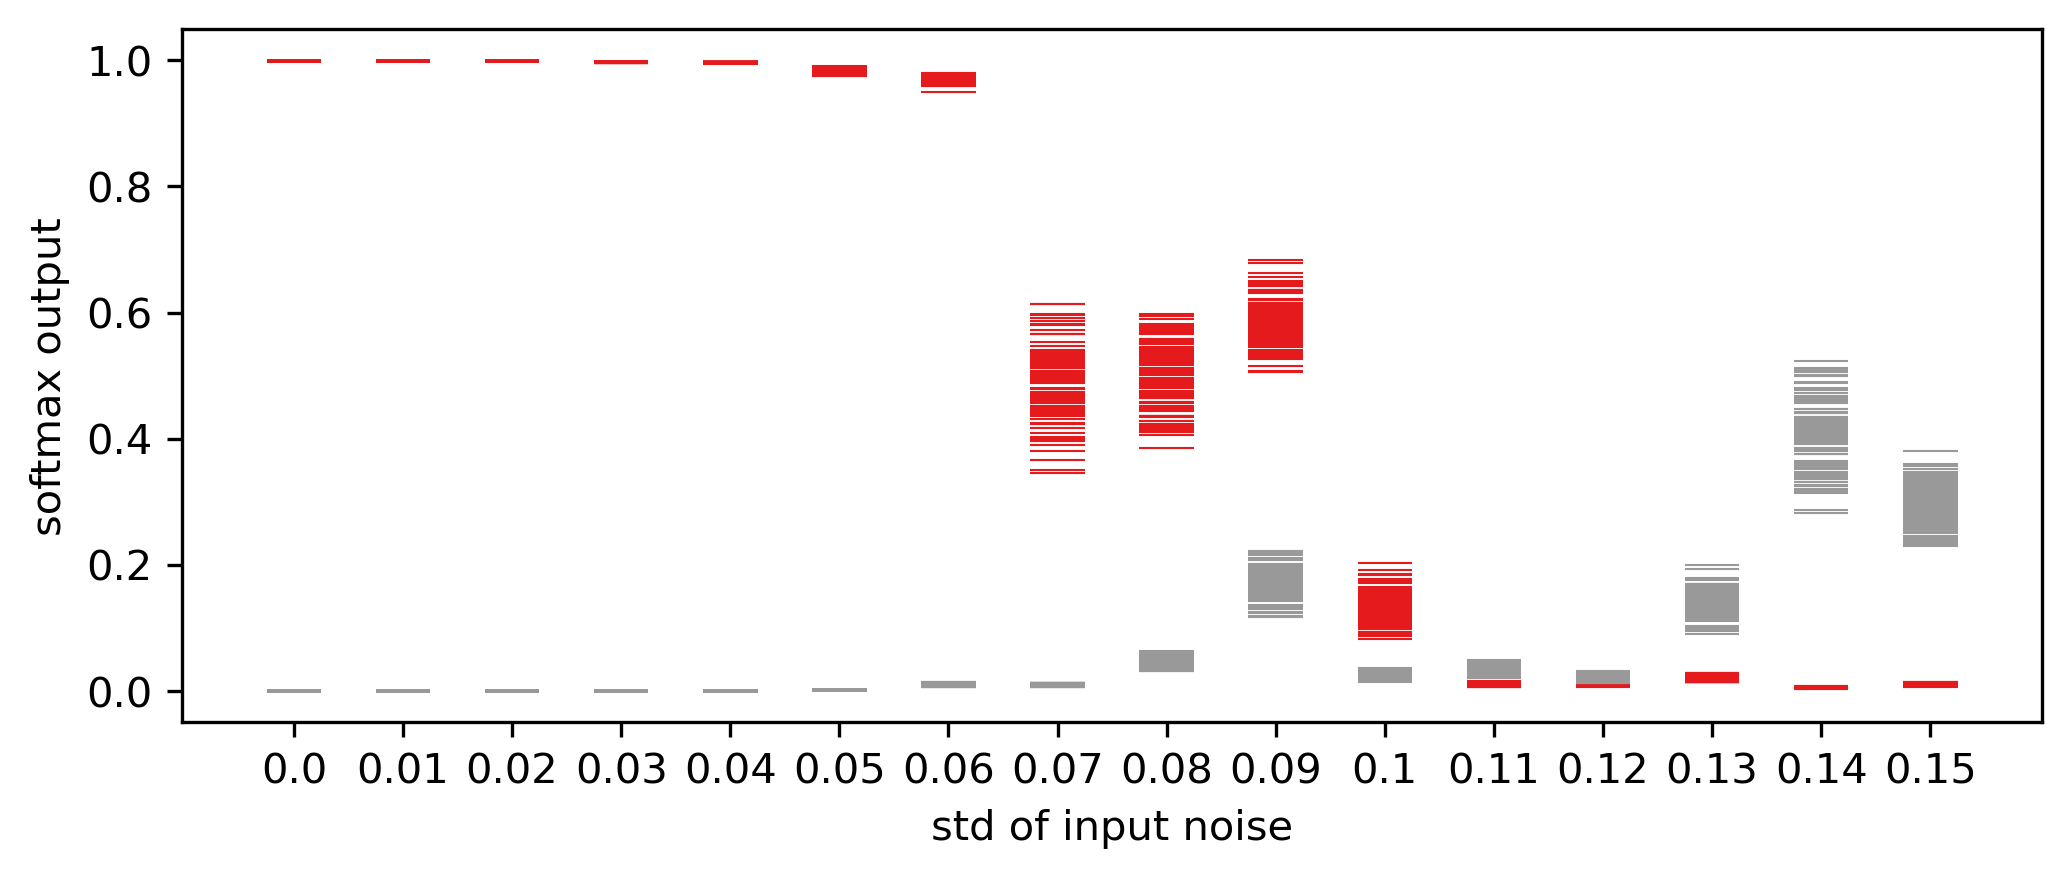

=> loading checkpoint '/home/xueqiong/noise_injection_uncertainty/cifar10/save/final_res_resnet8/cifar10_noise_resnet8_4_160_SGD_notadv/321/checkpoint_epoch160.pth.tar'
=> loaded checkpoint '/home/xueqiong/noise_injection_uncertainty/cifar10/save/final_res_resnet8/cifar10_noise_resnet8_4_160_SGD_notadv/321/checkpoint_epoch160.pth.tar' (epoch 160)
Module: CifarResNet
  Module: noise_Conv2d
  Module: BatchNorm2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: noise_Conv2d
      Module: BatchNorm2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: DownsampleA
        Module: AvgPool2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: DownsampleA
        Module: AvgPool2d
  Module: AvgP

/tmp/ipykernel_2409750/2271653032.py:57: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(resume, map_location='cpu')


8
Module: CifarResNet
  Module: noise_Conv2d
  Module: BatchNorm2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: noise_Conv2d
      Module: BatchNorm2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: DownsampleA
        Module: AvgPool2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: DownsampleA
        Module: AvgPool2d
  Module: AvgPool2d
  Module: noise_Linear
8
Module: CifarResNet
  Module: noise_Conv2d
  Module: BatchNorm2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: noise_Conv2d
      Module: BatchNorm2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: Batc

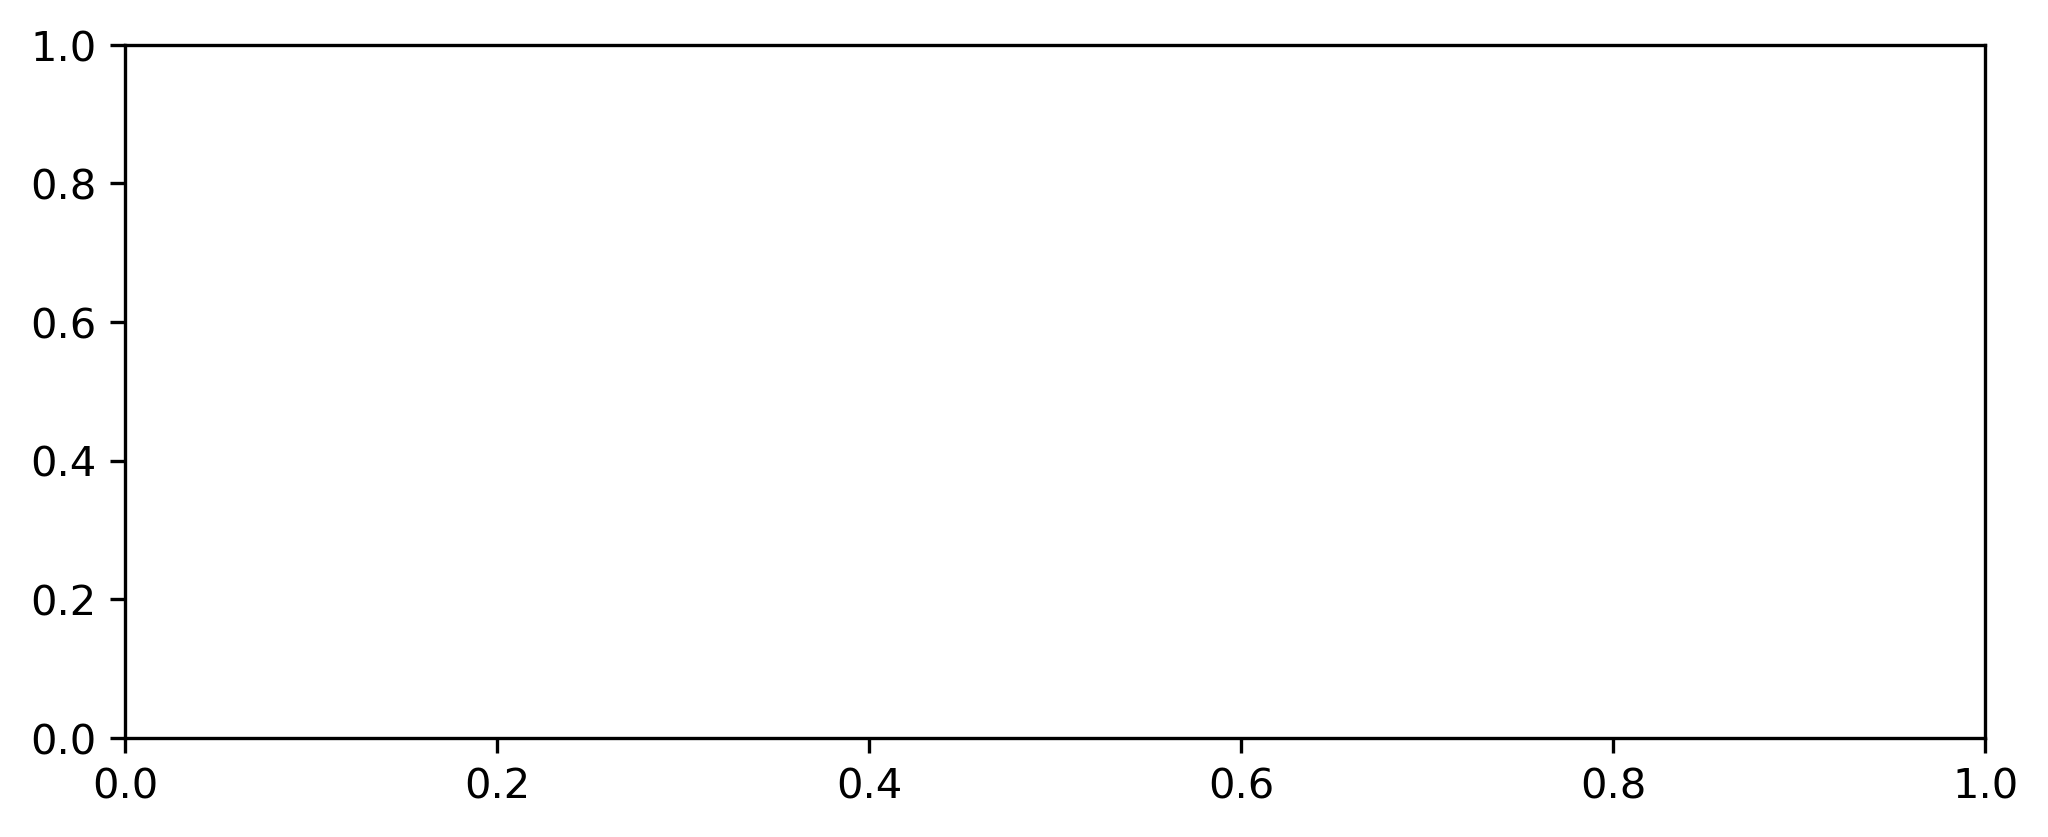

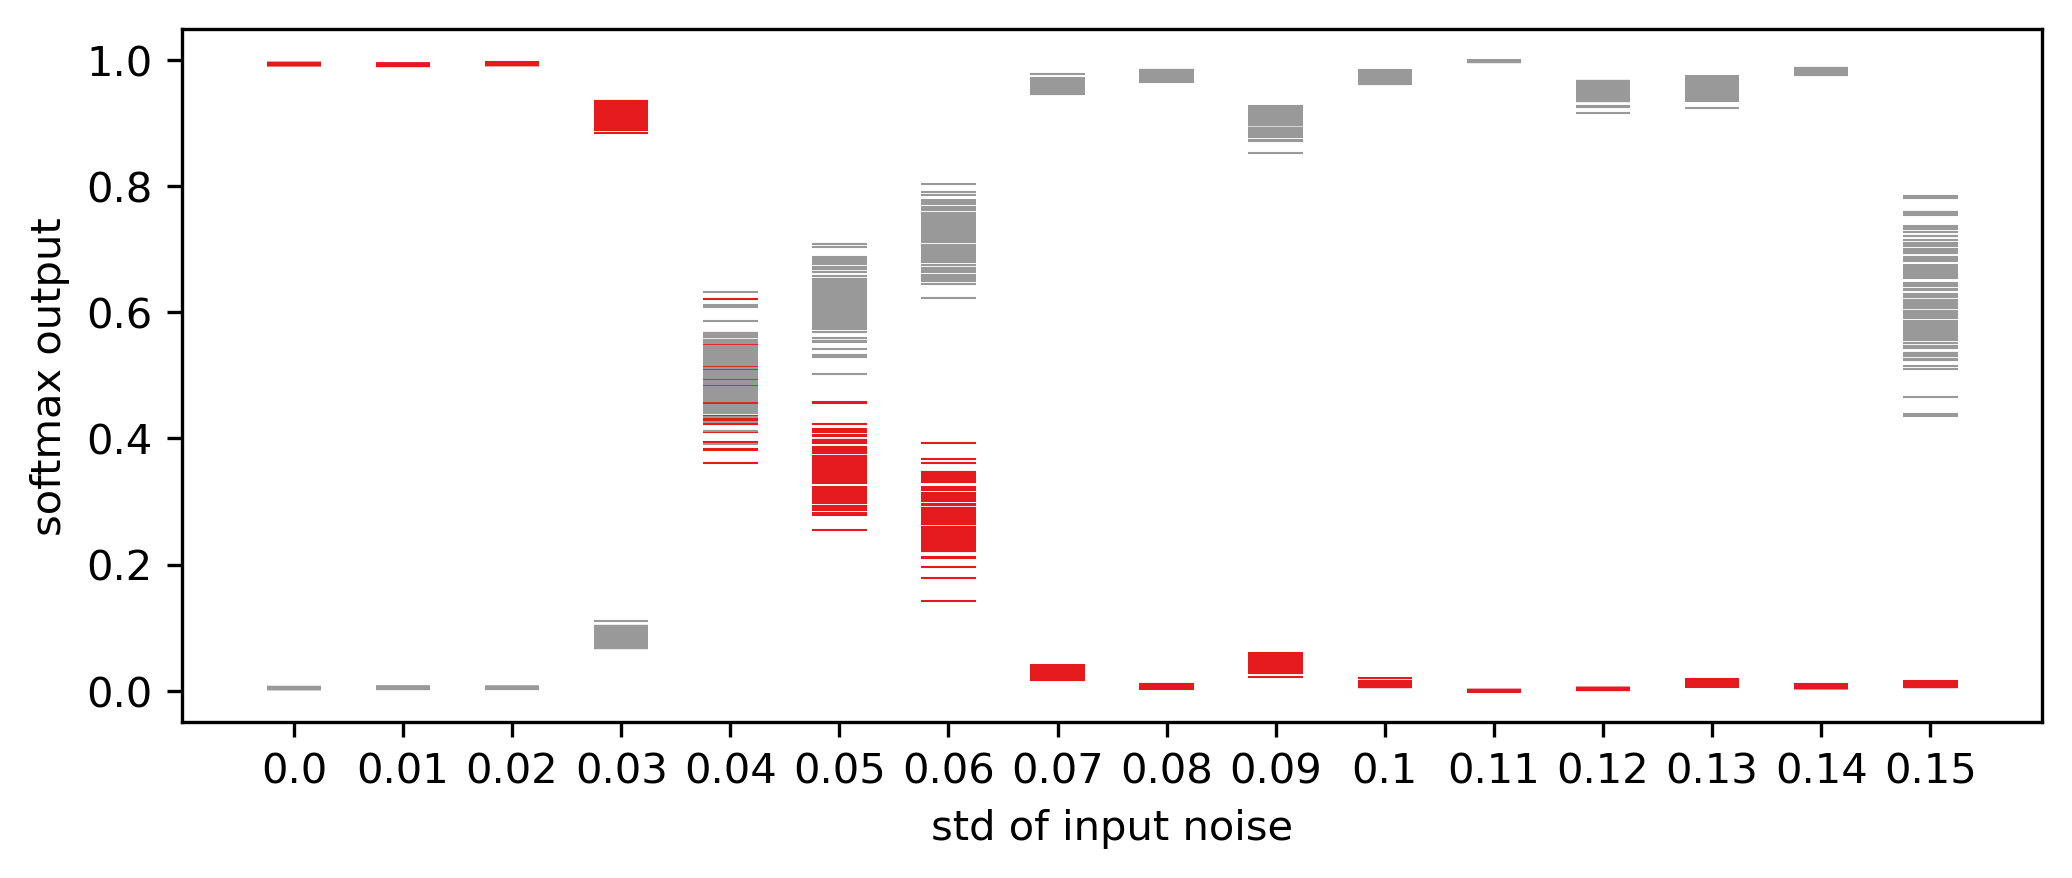

=> loading checkpoint '/home/xueqiong/noise_injection_uncertainty/cifar10/save/final_res_resnet8/cifar10_noise_resnet8_4_160_SGD_notadv/2239/checkpoint_epoch160.pth.tar'
=> loaded checkpoint '/home/xueqiong/noise_injection_uncertainty/cifar10/save/final_res_resnet8/cifar10_noise_resnet8_4_160_SGD_notadv/2239/checkpoint_epoch160.pth.tar' (epoch 160)
Module: CifarResNet
  Module: noise_Conv2d
  Module: BatchNorm2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: noise_Conv2d
      Module: BatchNorm2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: DownsampleA
        Module: AvgPool2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: DownsampleA
        Module: AvgPool2d
  Module: Av

/tmp/ipykernel_2409750/2271653032.py:57: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(resume, map_location='cpu')


8
Module: CifarResNet
  Module: noise_Conv2d
  Module: BatchNorm2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: noise_Conv2d
      Module: BatchNorm2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: DownsampleA
        Module: AvgPool2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: DownsampleA
        Module: AvgPool2d
  Module: AvgPool2d
  Module: noise_Linear
8
Module: CifarResNet
  Module: noise_Conv2d
  Module: BatchNorm2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: noise_Conv2d
      Module: BatchNorm2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: Batc

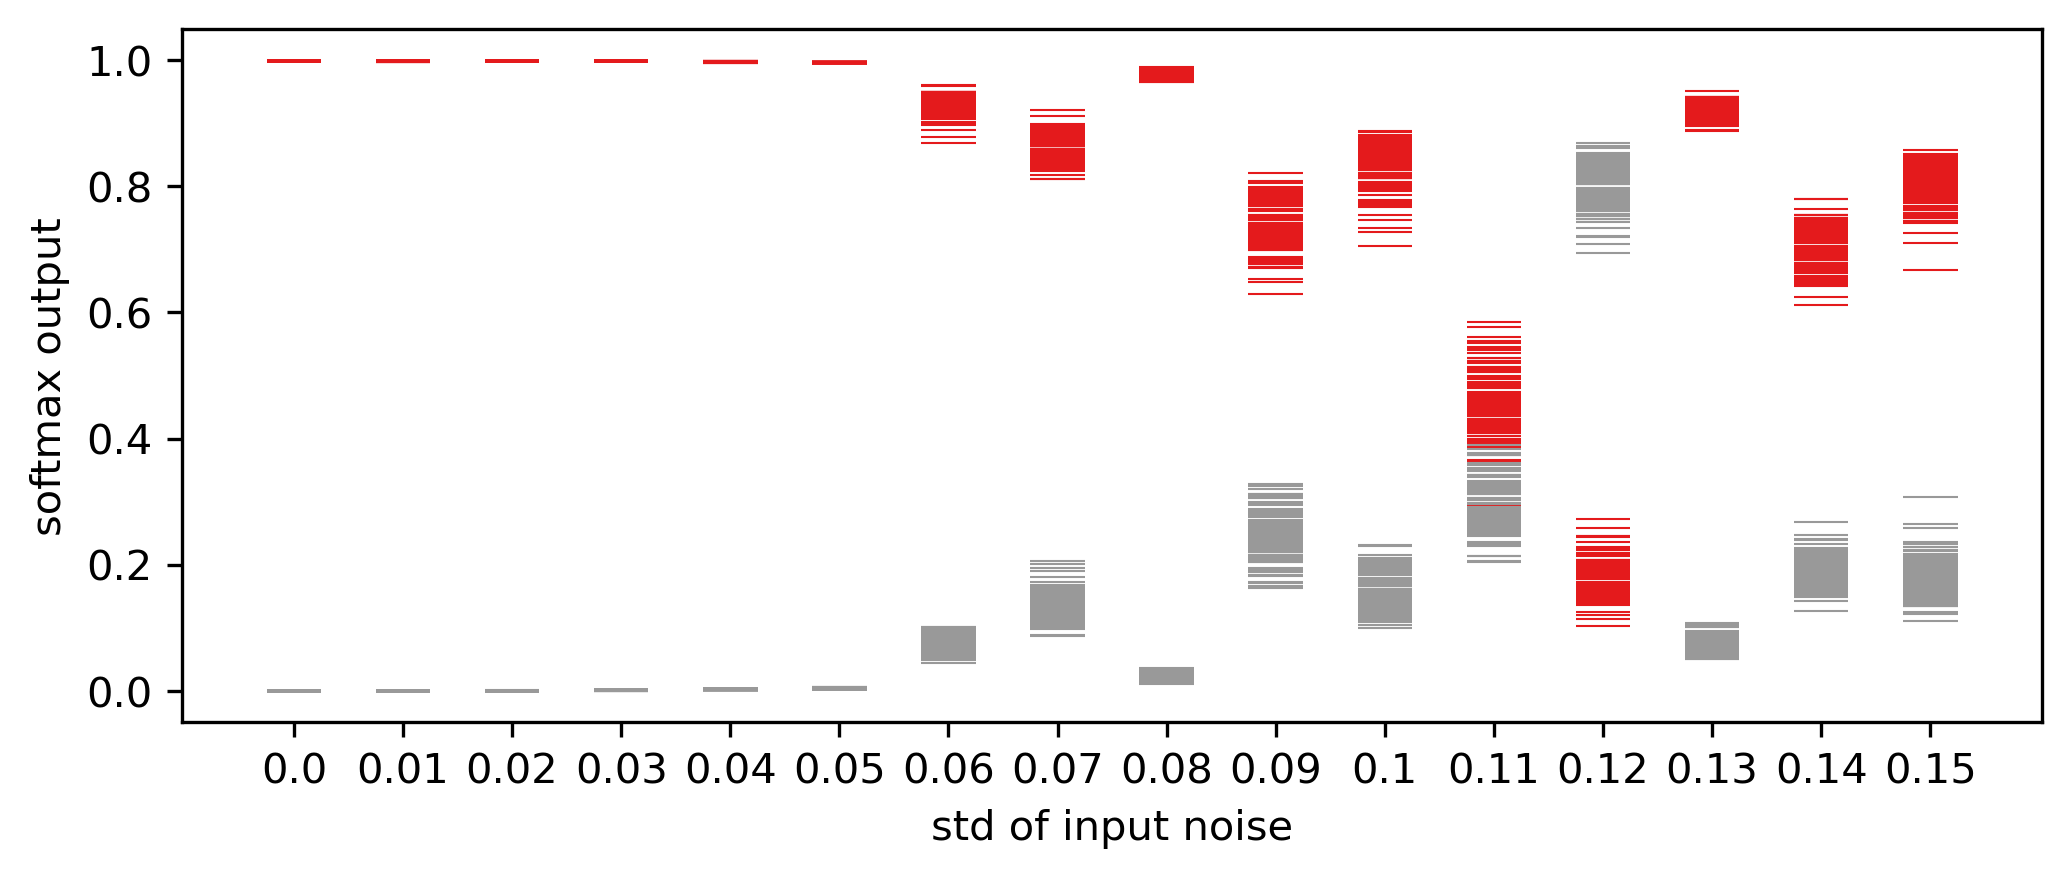

=> loading checkpoint '/home/xueqiong/noise_injection_uncertainty/cifar10/save/final_res_resnet8/cifar10_noise_resnet8_4_160_SGD_notadv/6900/checkpoint_epoch160.pth.tar'
=> loaded checkpoint '/home/xueqiong/noise_injection_uncertainty/cifar10/save/final_res_resnet8/cifar10_noise_resnet8_4_160_SGD_notadv/6900/checkpoint_epoch160.pth.tar' (epoch 160)
Module: CifarResNet
  Module: noise_Conv2d
  Module: BatchNorm2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: noise_Conv2d
      Module: BatchNorm2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: DownsampleA
        Module: AvgPool2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: DownsampleA
        Module: AvgPool2d
  Module: Av

/tmp/ipykernel_2409750/2271653032.py:57: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(resume, map_location='cpu')


8
Module: CifarResNet
  Module: noise_Conv2d
  Module: BatchNorm2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: noise_Conv2d
      Module: BatchNorm2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: DownsampleA
        Module: AvgPool2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: DownsampleA
        Module: AvgPool2d
  Module: AvgPool2d
  Module: noise_Linear
8
Module: CifarResNet
  Module: noise_Conv2d
  Module: BatchNorm2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: noise_Conv2d
      Module: BatchNorm2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: Batc

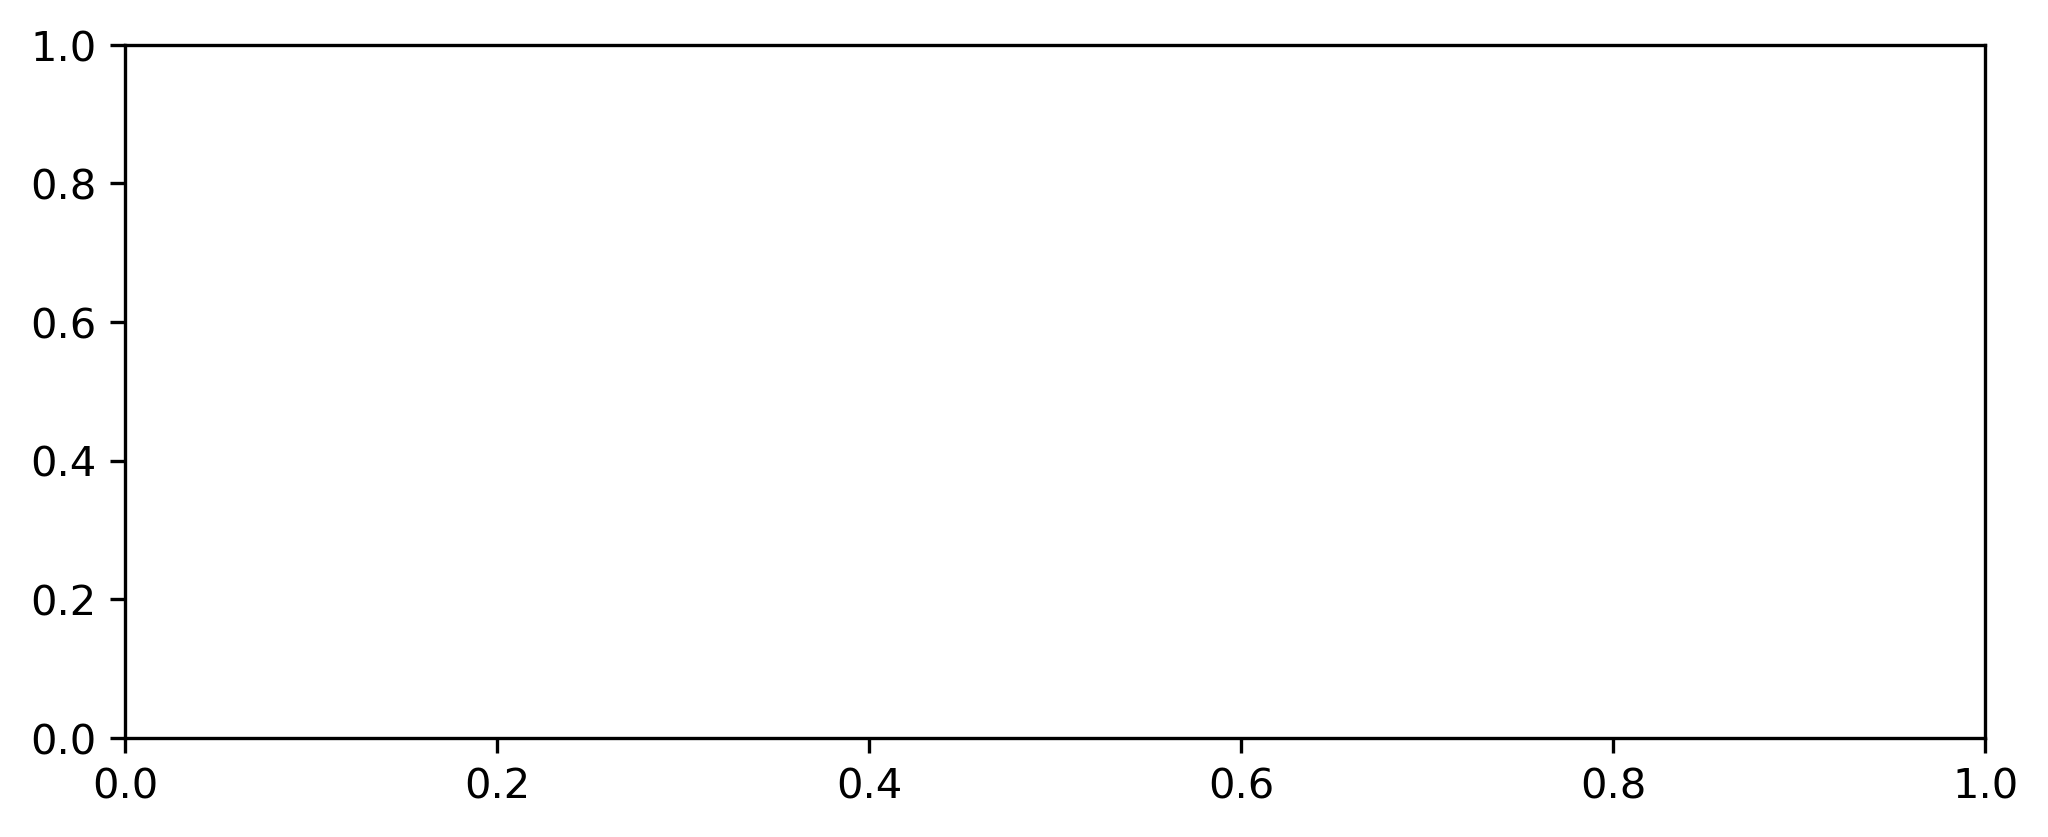

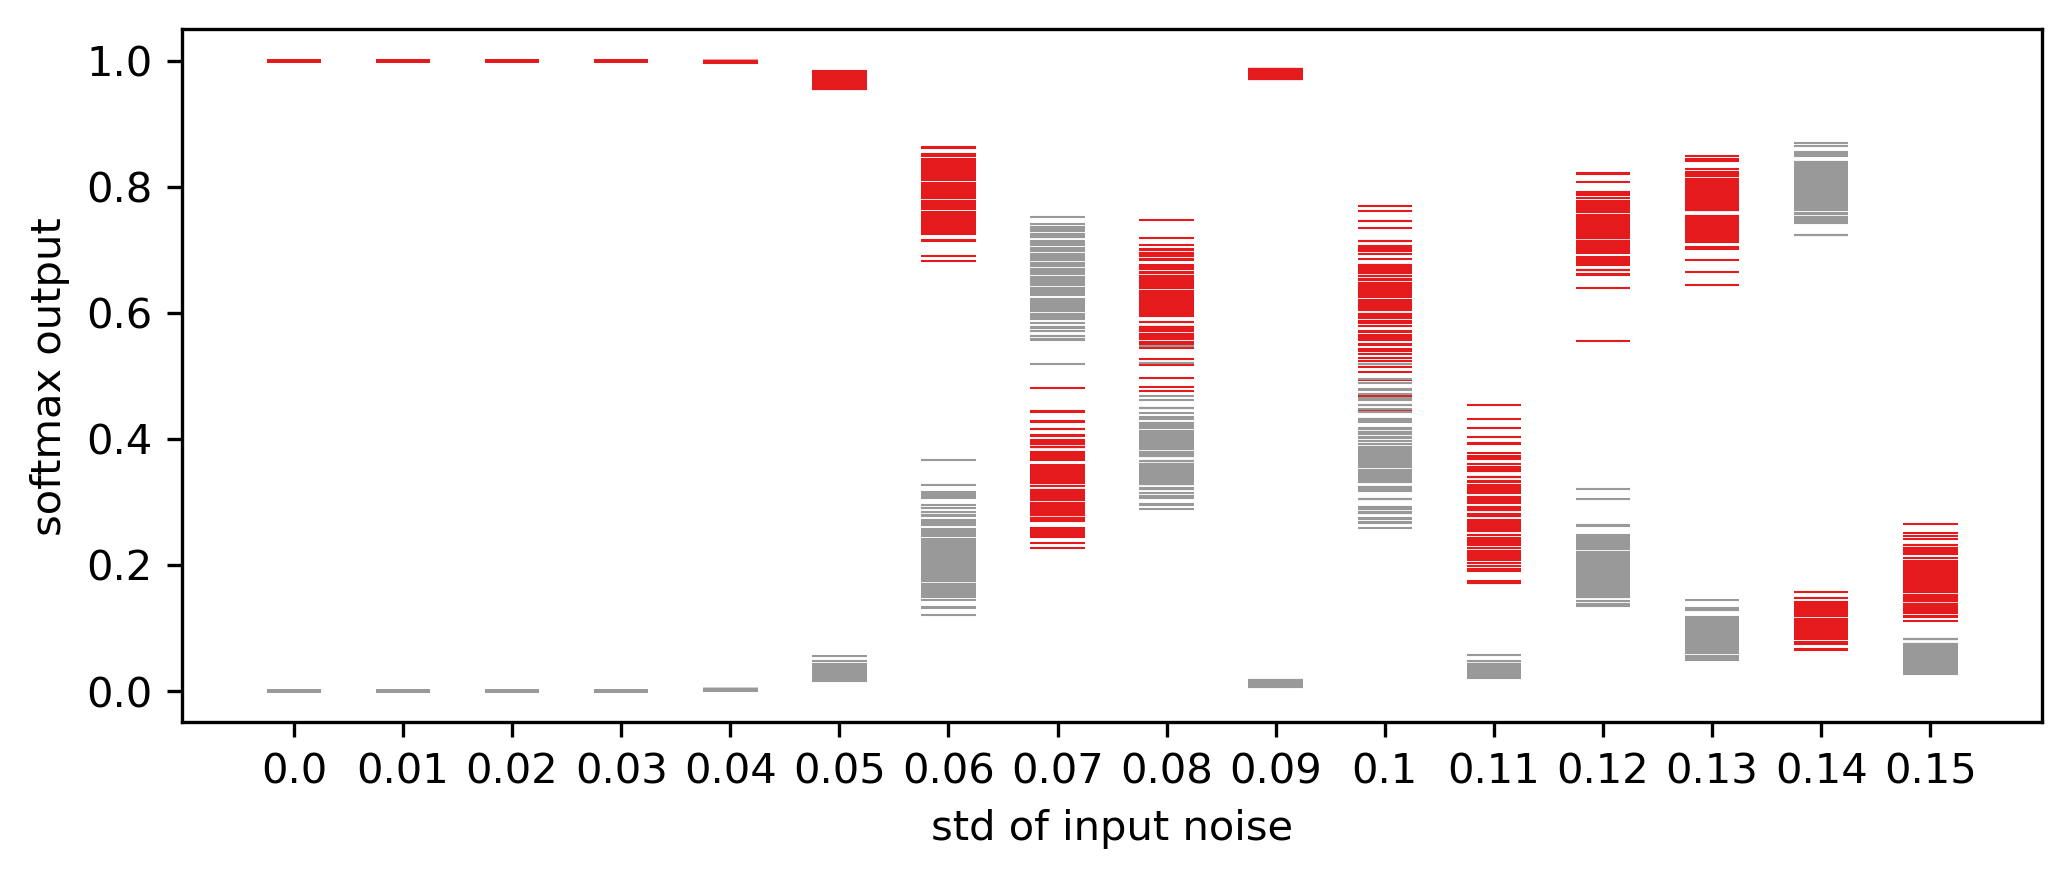

=> loading checkpoint '/home/xueqiong/noise_injection_uncertainty/cifar10/save/final_res_resnet8/cifar10_noise_resnet8_4_160_SGD_notadv/8352/checkpoint_epoch160.pth.tar'
=> loaded checkpoint '/home/xueqiong/noise_injection_uncertainty/cifar10/save/final_res_resnet8/cifar10_noise_resnet8_4_160_SGD_notadv/8352/checkpoint_epoch160.pth.tar' (epoch 160)
Module: CifarResNet
  Module: noise_Conv2d
  Module: BatchNorm2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: noise_Conv2d
      Module: BatchNorm2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: DownsampleA
        Module: AvgPool2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: DownsampleA
        Module: AvgPool2d
  Module: Av

/tmp/ipykernel_2409750/2271653032.py:57: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(resume, map_location='cpu')


8
Module: CifarResNet
  Module: noise_Conv2d
  Module: BatchNorm2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: noise_Conv2d
      Module: BatchNorm2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: DownsampleA
        Module: AvgPool2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: DownsampleA
        Module: AvgPool2d
  Module: AvgPool2d
  Module: noise_Linear
8
Module: CifarResNet
  Module: noise_Conv2d
  Module: BatchNorm2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: BatchNorm2d
      Module: noise_Conv2d
      Module: BatchNorm2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: noise_Conv2d
      Module: Batc

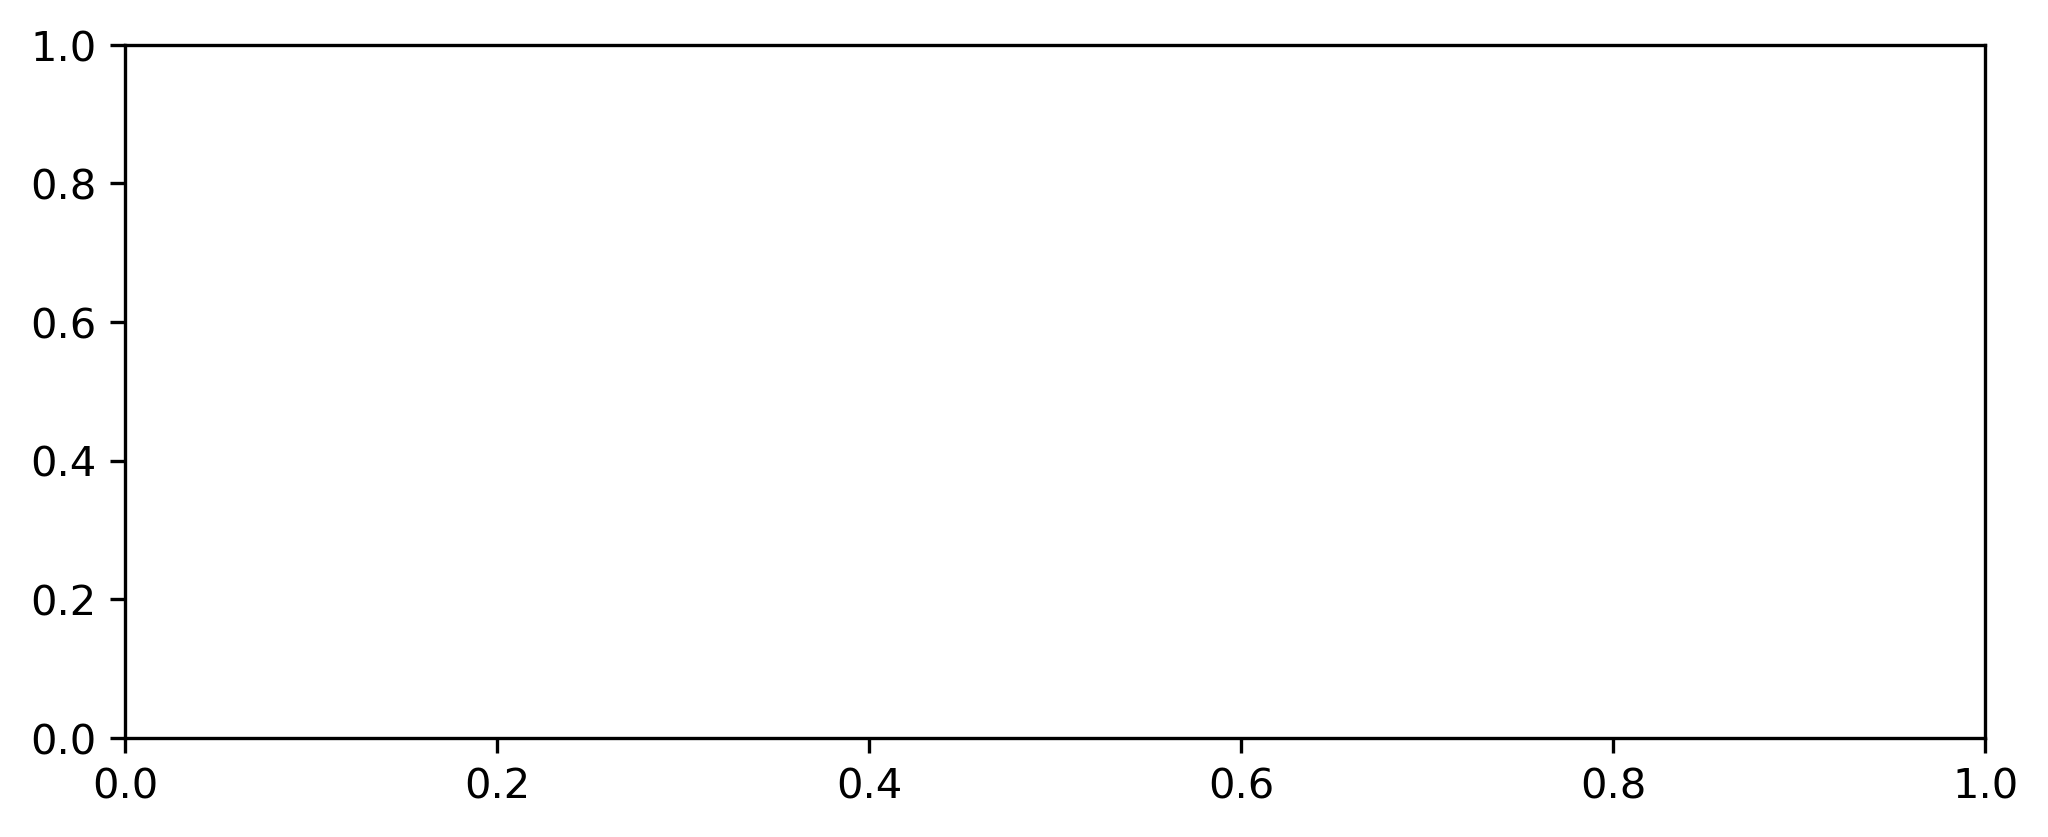

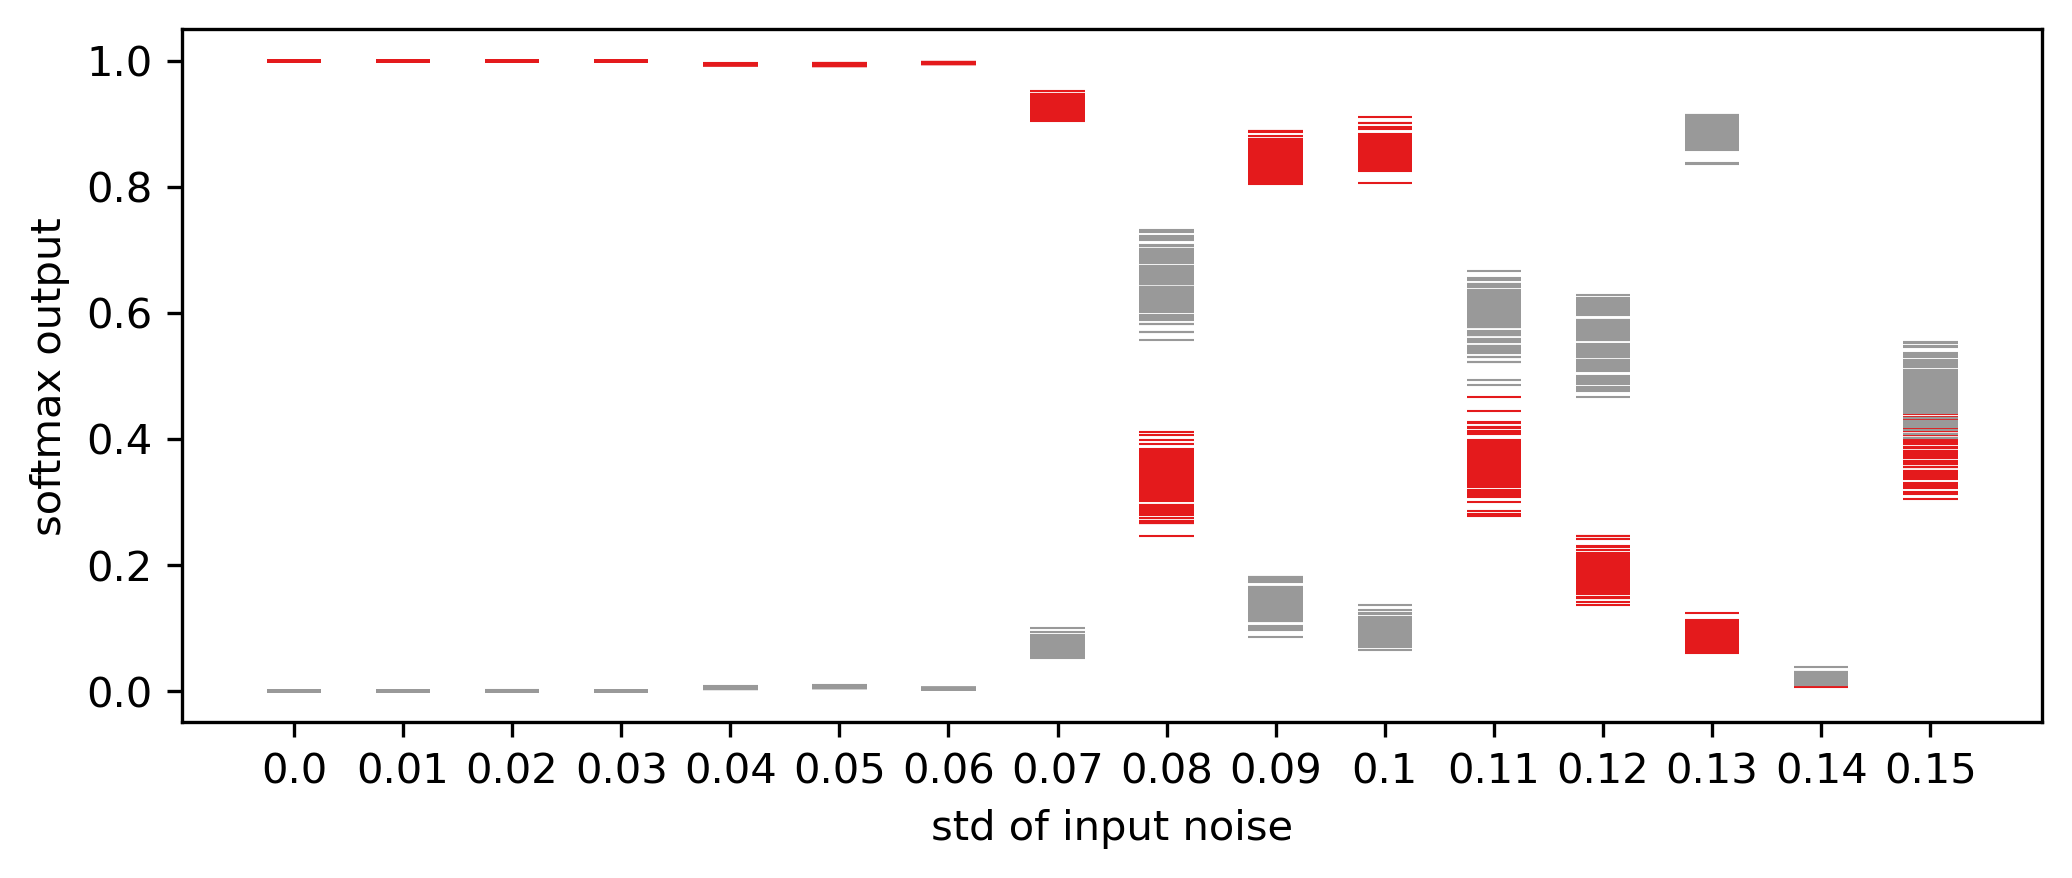

In [14]:
# %%
plt.style.use('default')

# folders = ['cifar10_vanilla_resnet8_4_160_SGD_notadv', 'cifar10_noise_resnet8_4_160_SGD_notadv', 'cifar10_fixnoise_resnet8_4_160_SGD_notadv_0.05', 'cifar10_fixnoise_resnet8_4_160_SGD_notadv_0.1', 'cifar10_fixnoise_resnet8_4_160_SGD_notadv_0.2', 'cifar10_fixnoise_resnet8_4_160_SGD_notadv_0.5', 'cifar10_dropout_resnet8_4_160_SGD_notadv']
# folders_label = ['vanilla', 'PNI', 'fixnoise_0.05', 'fixnoise_0.1', 'fixnoise_0.2', 'fixnoise_0.5', 'dropout']

# folders = ['cifar10_vanilla_resnet8_4_160_SGD_notadv', 'cifar10_noise_resnet8_4_160_SGD_notadv', 'cifar10_fixnoise_resnet8_4_160_SGD_notadv_0.05', 'cifar10_dropout_resnet8_4_160_SGD_notadv']
folders = ['cifar10_noise_resnet8_4_160_SGD_notadv']
folders_label = ['vanilla', 'MCNI(learned)', 'MCNI(fixed)', 'MC dropout']
np.random.seed(42)
img_ids = [8195]
for img_id in img_ids:
    target = test_data[img_id][1]
    # targets = list(set(img_id_to_dict[img_id]['cifar10_noise_resnet8_4_160_SGD_notadv'].values()))
    targets = [8, 9]
    targets.sort()
    if len(targets)==1:
        continue
    print(img_id)
    for i, folder in enumerate(folders):
        args.resume_path = '/home/xueqiong/noise_injection_uncertainty/cifar10/save/final_res_resnet8/{}'.format(folder)
        if 'fixnoise_resnet20' in folder:
            args.arch = 'fixnoise_resnet20'
            args.fix_noise_level = float(folder.split('_')[-1])
            print('fix_noise_level: ', args.fix_noise_level)
        elif 'fixnoise_resnet8' in folder:
            args.arch = 'fixnoise_resnet8'
            args.fix_noise_level = float(folder.split('_')[-1])
            print('fix_noise_level: ', args.fix_noise_level)
        elif 'noise_resnet20' in folder:
            args.arch = 'noise_resnet20'
        elif 'noise_resnet8' in folder:
            args.arch = 'noise_resnet8'
        elif 'dropout_resnet20' in folder:
            args.arch = 'dropout_resnet20'
        elif 'dropout_resnet8' in folder:
            args.arch = 'dropout_resnet8'
        elif 'vanilla_resnet20' in folder:
            args.arch = 'vanilla_resnet20'
        elif 'vanilla_resnet8' in folder:
            args.arch = 'vanilla_resnet8'
        args.num_filters = 4
        
        print('arch: ', args.arch)
        net = init_model(args, num_classes, args.num_filters)
        print_log("=> network :\n {}".format(net), log)

        for package in os.listdir(args.resume_path):
            fig, ax = plt.subplots(figsize=(8, 3), dpi=300)
            if package == 'test' or '.npy' in package or '.csv' in package:
                continue
            resume = os.path.join(args.resume_path, package, 'checkpoint_epoch160.pth.tar')
            print_log("=> loading checkpoint '{}'".format(resume), log)
            if args.use_cuda == True:
                checkpoint = torch.load(resume)
            else:
                checkpoint = torch.load(resume, map_location='cpu')
            if not (args.fine_tune):
                args.start_epoch = checkpoint['epoch']
                recorder = checkpoint['recorder']

            state_tmp = net.state_dict()
            if 'state_dict' in checkpoint.keys():
                state_tmp.update(checkpoint['state_dict'])
            else:
                state_tmp.update(checkpoint)

            net.load_state_dict(state_tmp)
            print_log("=> loaded checkpoint '{}' (epoch {})".format(
                resume, args.start_epoch), log)

            if args.use_cuda:
                if args.ngpu > 1:
                    net = torch.nn.DataParallel(net, device_ids=list(range(args.ngpu)))

            # define loss function (criterion) and optimizer
            criterion = torch.nn.CrossEntropyLoss()
            if args.use_cuda:
                net.cuda()
                criterion.cuda()
            inputs = test_data.data[img_id]
            stds = np.arange(0, 0.16, 0.01)
            for x, std in enumerate(stds):
                noise_inputs = noise_img(inputs, std).permute(1, 2, 0).numpy()
                noise_inputs = test_transform(noise_inputs)
                test_times = 100
                if 'vanilla' in folder:
                    test_times = 1
                softmax, lines = plot_softmaxs_ax(noise_inputs, targets, net, x=x, ax=ax, test_times=test_times)
                np.save('./save_qualitative/{}_img{}_std{}_{}.npy'.format(folder, img_id, std, time.time()), softmax)
                pred = np.sum(softmax, axis=1).argmax()
                print(pred)
            plt.xticks(range(len(stds)), stds)
            plt.xlabel("std of input noise")
            plt.ylabel("softmax output")
            plt.show()
            plt.legend(lines, ["label {}".format(target) for target in targets], loc="best")
            break